Data loading complete. Total valid data points after filtering 0-values: 640


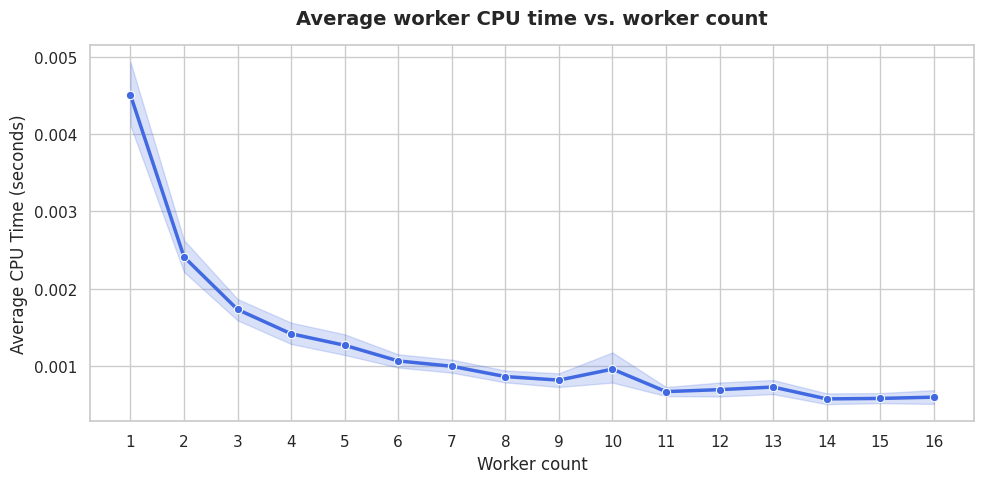

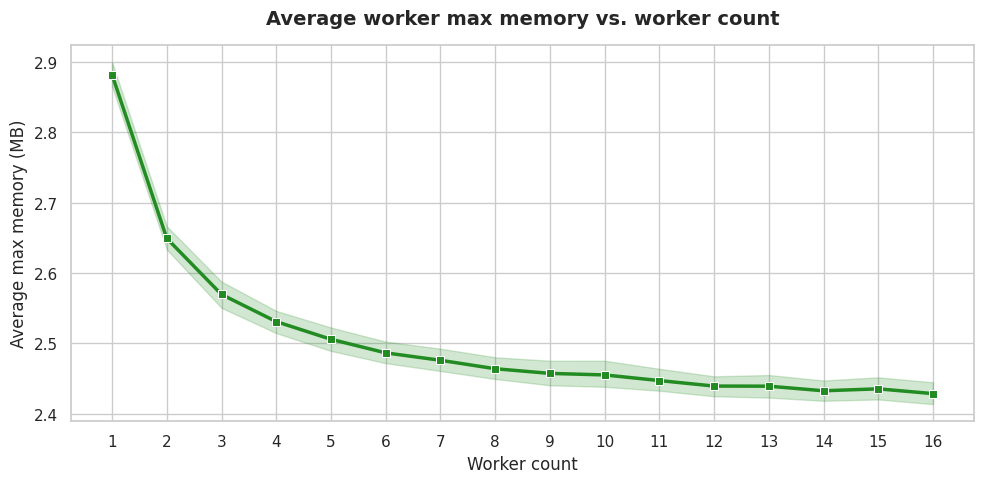

In [1]:
# %% [markdown]
# # Worker Performance Scaling Analysis (with 0-Value Filtering)
# This notebook loads the `benchmark_results.json` file, filters out invalid or zero values, 
# and visualizes how the average worker CPU time and maximum memory footprint scale with the number of workers.

# %%
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up global plotting aesthetics
sns.set_theme(style="whitegrid")

# %% [markdown]
# ## 1. Load, Parse, and Filter Benchmark Data
# We extract the metrics inside `worker_analysis` dynamically and explicitly filter out any values equal to `0`.

# %%
# Load the JSON benchmark data
with open("benchmark_results.json", "r") as f:
    raw_data = json.load(f)

# Process and flatten the nested worker metrics
rows = []
for entry in raw_data["data"]:
    workers_size = entry["workers_size"]
    cluster_size = entry["cluster_size"]
    run = entry["run"]
    timings = entry["timings"]
    worker_analysis = timings.get("worker_analysis", {})
    
    # Extract worker metrics dynamically, FILTERING OUT values equal to 0
    cpu_times = [v for k, v in worker_analysis.items() if "cpu_time" in k and v != 0]
    mem_mbs = [v for k, v in worker_analysis.items() if "max_memory_mb" in k and v != 0]
    
    # Calculate averages for the current run only if we have valid non-zero data points
    avg_cpu = np.mean(cpu_times) if cpu_times else None
    avg_mem = np.mean(mem_mbs) if mem_mbs else None
    
    rows.append({
        "cluster_size": cluster_size,
        "workers_size": workers_size,
        "run": run,
        "avg_worker_cpu_time_s": avg_cpu,
        "avg_worker_max_memory_mb": avg_mem
    })

# Convert to structured DataFrame
df = pd.DataFrame(rows)

# Drop any rows where the computed metrics are completely missing (NaN)
df = df.dropna(subset=["avg_worker_cpu_time_s", "avg_worker_max_memory_mb"])

# Additional safety filter: Ensure no final averaged row values are equal to 0
df = df[(df["avg_worker_cpu_time_s"] != 0) & (df["avg_worker_max_memory_mb"] != 0)]

print(f"Data loading complete. Total valid data points after filtering 0-values: {len(df)}")
df.head()

# %% [markdown]
# ## 2. Plot Average Worker CPU Time vs. Worker Count

# %%
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df, 
    x="workers_size", 
    y="avg_worker_cpu_time_s", 
    marker="o", 
    color="royalblue", 
    linewidth=2.5
)

plt.title("Average worker CPU time vs. worker count", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Worker count", fontsize=12)
plt.ylabel("Average CPU Time (seconds)", fontsize=12)
plt.xticks(sorted(df["workers_size"].unique()))
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 3. Plot Average Worker Max Memory vs. Worker Count

# %%
plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df, 
    x="workers_size", 
    y="avg_worker_max_memory_mb", 
    marker="s", 
    color="forestgreen", 
    linewidth=2.5
)

plt.title("Average worker max memory vs. worker count", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Worker count", fontsize=12)
plt.ylabel("Average max memory (MB)", fontsize=12)
plt.xticks(sorted(df["workers_size"].unique()))
plt.tight_layout()
plt.show()

/tmp/ipykernel_91687/3904995131.py:8: UserWarning: The markers list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(


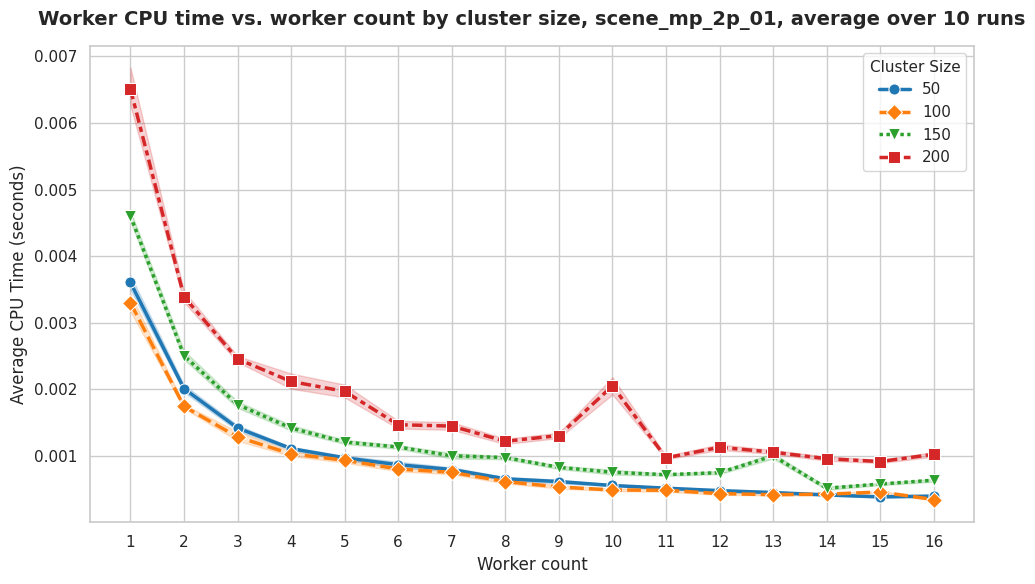

/tmp/ipykernel_91687/3904995131.py:31: UserWarning: The markers list has more values (6) than needed (4), which may not be intended.
  sns.lineplot(


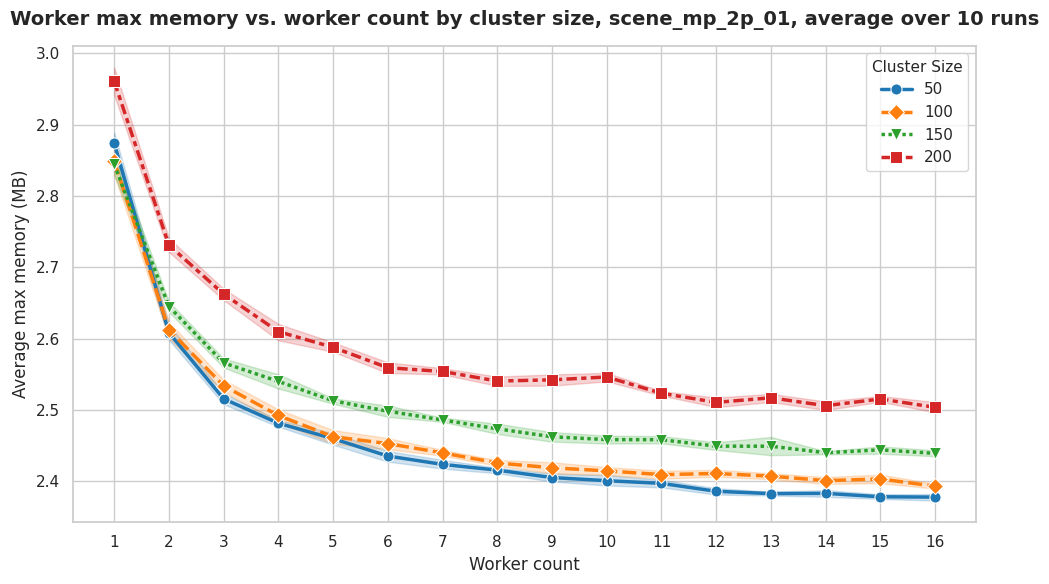

In [2]:
# %% [markdown]
# ## 4. Scaling Metrics by Cluster Size
# This section visualizes how both worker CPU time and memory footprint scale with the worker count, broken down with a unique line for each `cluster_size`.

# %%
# 4a. Worker CPU Time vs. Worker Count by Cluster Size
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df, 
    x="workers_size", 
    y="avg_worker_cpu_time_s", 
    hue="cluster_size",
    style="cluster_size",                  # 1. Added style to map markers to each cluster size
    markers=['o', 'D', 'v', 's', '^', '*'], # 2. Replaced 'x' with 'D' to prevent mixing filled & line art
    markersize=8,                          # Optional: increases marker visibility
    palette="tab10", 
    linewidth=2.5
)

plt.title("Worker CPU time vs. worker count by cluster size, scene_mp_2p_01, average over 10 runs", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Worker count", fontsize=12)
plt.ylabel("Average CPU Time (seconds)", fontsize=12)
plt.xticks(sorted(df["workers_size"].unique()))
plt.legend(title="Cluster Size", title_fontsize='11', loc='best')
plt.tight_layout()
plt.show()

# %%
# 4b. Worker Max Memory vs. Worker Count by Cluster Size
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df, 
    x="workers_size", 
    y="avg_worker_max_memory_mb", 
    hue="cluster_size",
    style="cluster_size",                  # 1. Added style to map markers to each cluster size
    markers=['o', 'D', 'v', 's', '^', '*'], # 2. Replaced 'x' with 'D' to prevent mixing filled & line art
    markersize=8,                          # Optional: increases marker visibility
    palette="tab10", 
    linewidth=2.5
)

plt.title("Worker max memory vs. worker count by cluster size, scene_mp_2p_01, average over 10 runs", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Worker count", fontsize=12)
plt.ylabel("Average max memory (MB)", fontsize=12)
plt.xticks(sorted(df["workers_size"].unique()))
plt.legend(title="Cluster Size", title_fontsize='11', loc='best')
plt.tight_layout()
plt.show()

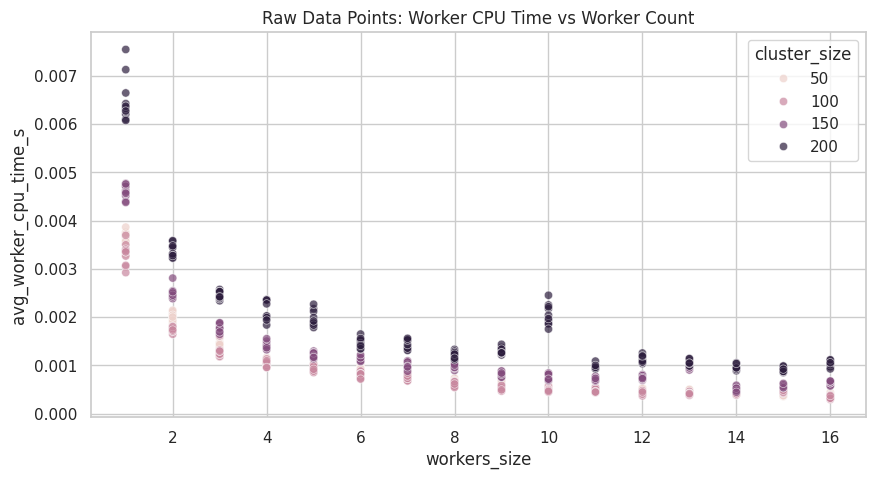

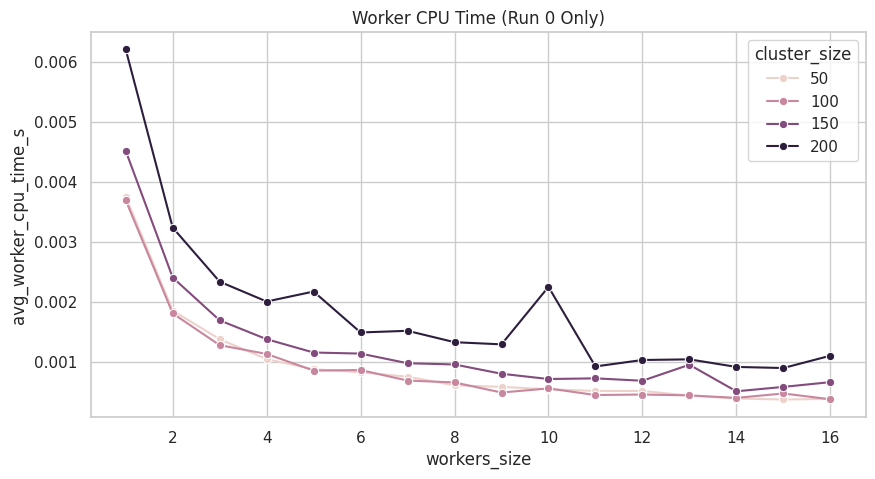

In [3]:
# %% [markdown]
# ### Debugging: Inspecting Raw Points vs. Aggregations

# %%
# 1. Look at the raw scatter points to see if Seaborn's aggregation is hiding the curve
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df, 
    x="workers_size", 
    y="avg_worker_cpu_time_s", 
    hue="cluster_size", 
    alpha=0.7
)
plt.title("Raw Data Points: Worker CPU Time vs Worker Count")
plt.show()

# 2. Isolate just the very first run to see its independent scaling trend
df_run_0 = df[df["run"] == 1]

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=df_run_0, 
    x="workers_size", 
    y="avg_worker_cpu_time_s", 
    hue="cluster_size", 
    marker="o"
)
plt.title("Worker CPU Time (Run 0 Only)")
plt.show()